# One model, four jobs: simulate, fit, design, optimize

A model is the durable thing. Simulation, regression, design of experiments and
optimization are not four models — they are four *questions* put to the same one.
What changes between them is only

* **which quantities are free**, and
* **what is being optimized**.

This notebook makes that literal. The reactor is written down once as a discopt
`Model`, and then the *same model* is simulated, regressed, designed on, and
optimized. Between stages it does not stay in memory: it is
**serialized to a file and loaded back**, the way a calibrated model travels
between the study that produced it and the work that uses it
{cite:p}`Wilkinson2016`.

| job | free | fixed | objective |
|---|---|---|---|
| **simulate** | the state $C_A, C_B, C_C$ | $k_1, k_2$, $F$ | none — a square solve |
| **regress** | $k_1, k_2$ | $F$ at each measured condition | min weighted SSE |
| **design** (MBDoE) | $F$ | $k_1, k_2$ at $\hat\theta$ | max $\det \mathrm{FIM}$ |
| **optimize** | $F$ | $k_1, k_2$ at $\hat\theta$ | max $C_B$ |

The statistical background is {cite:t}`Bard1974` and {cite:t}`Biegler2010`; for
MBDoE see {cite:t}`Franceschini2008` and {cite:t}`Atkinson2007`, with the original
non-linear design argument in {cite:t}`BoxLucas1959`.

:::{note}
The design section needs the optional plugin: `pip install discopt-doe`.
:::

**The data comes from a file, not from this notebook.** `cstr_lab.py`, next to
this notebook, is the "laboratory": it owns the true rate constants and the
measurement noise, and writes CSV assay files. Nothing here imports it, so the
notebook cannot read the answer it is meant to estimate. At the very end we ask
it to open the envelope.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown

import discopt
import discopt.modeling as dm
from discopt import doe
from discopt.estimate import Experiment, ExperimentModel, estimate_parameters

# Executed from this notebook's directory (jupyter-book) or from the repo root.
HERE = Path.cwd() if (Path.cwd() / "cstr_lab.py").exists() else Path("docs/notebooks")
LAB = HERE / "cstr_lab.py"
DATA = HERE / "data"
CALIBRATED_V1 = HERE / "cstr_calibrated_v1.dopt"
CALIBRATED_V2 = HERE / "cstr_calibrated_v2.dopt"
assert LAB.exists(), f"cannot find the lab script from {Path.cwd()}"

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.autolayout": True})

## 1. Write the model down once

A single isothermal CSTR of volume $V$, fed pure **A** at concentration $C_{A0}$
and volumetric flow rate $F$, with the first-order series reaction

$$\mathrm{A} \xrightarrow{k_1} \mathrm{B} \xrightarrow{k_2} \mathrm{C}.$$

With residence time $\tau = V/F$, the steady-state balances
$F(C_{A0}-C_A) = V k_1 C_A$ and $F(0-C_B) = V(k_2 C_B - k_1 C_A)$ solve in closed
form {cite:p}`Fogler2016`:

$$C_A = \frac{C_{A0}}{1+k_1\tau}, \qquad
  C_B = \frac{k_1 \tau\, C_{A0}}{(1+k_1\tau)(1+k_2\tau)}, \qquad
  C_C = C_{A0} - C_A - C_B .$$

In the model, **everything is a variable**: the state $C_A, C_B, C_C$, the
operating condition $F$, and the rate constants $k_1, k_2$. The three equations
above go in as named equality rows. Nothing in the model says which of these is
known — that is the *job's* choice, made later by pinning bounds, and it is the
only thing that changes from section to section.

The reactor's own specification — volume, feed concentration, and the assay's
repeatability — are `Parameter`s: values that are fixed during a solve but can be
re-valued between solves. Two more parameters, `fim` and `n_obs`, carry what we
learn about $k_1, k_2$ from the data; they appear in no equation, and they are
parameters because that is the slot discopt's file format keeps for a model's own
numbers (§5).

`n_runs` is the only structural knob: one instance of the reactor, or $n$ of them
sharing one pair of rate constants — which is exactly what a campaign of $n$ runs
is.

In [2]:
def build_reactor(n_runs=1, name="cstr"):
    """The reactor, as a model. `n_runs` copies share one pair of rate constants."""
    m = dm.Model(name)

    V = m.parameter("V", 1.0)  # reactor volume, L
    CA0 = m.parameter("CA0", 2.0)  # feed concentration of A, mol/L
    m.parameter("sigma", 0.03)  # assay repeatability, mol/L
    m.parameter("fim", np.zeros((2, 2)))  # Fisher information about (k1, k2)
    m.parameter("n_obs", 0.0)  # observations behind that information

    shape = () if n_runs == 1 else (n_runs,)
    k1 = m.continuous("k1", lb=1e-3, ub=20.0)  # 1/min
    k2 = m.continuous("k2", lb=1e-3, ub=20.0)  # 1/min
    F = m.continuous("F", shape=shape, lb=0.05, ub=5.0)  # L/min
    CA = m.continuous("CA", shape=shape, lb=0.0, ub=10.0)  # mol/L
    CB = m.continuous("CB", shape=shape, lb=0.0, ub=10.0)
    CC = m.continuous("CC", shape=shape, lb=0.0, ub=10.0)

    tau = V / F
    m.subject_to(CA == CA0 / (1.0 + k1 * tau), name="CA_def")
    m.subject_to(CB == k1 * tau * CA0 / ((1.0 + k1 * tau) * (1.0 + k2 * tau)), name="CB_def")
    m.subject_to(CC == CA0 - CA - CB, name="CC_def")
    return m


def parts(m):
    """Variables, parameters and rows of `m`, by name -- also after a reload."""
    return (
        {v.name: v for v in m._variables},
        {p.name: p for p in m._parameters},
        {c.name: c for c in m._constraints},
    )


reactor = build_reactor()
var, par, row = parts(reactor)
print(reactor.summary())
print("\nrows:", list(row))

Model: cstr
  Variables: 6 (6 continuous, 0 integer/binary)
  Constraints: 3
  Objective: <none set>
  Parameters: 5

rows: ['CA_def', 'CB_def', 'CC_def']


### One more thing the model has to hand back

Design of experiments needs the responses as **explicit functions of the
parameters**: the Fisher information is built from $\partial y/\partial\theta$ by
autodiff through the response expression, so a bare `CA` variable — whose
derivative with respect to $k_1$ is zero — would silently produce a singular
information matrix and a meaningless covariance.

The closed forms are already in the model, inside the definition rows. discopt
normalizes a row `y == expr` to the body `y - expr`, so the response expression
comes back as `y - body`. That is one line, it works on a model that was just
built *and* on one that was just read from disk, and it means the expression is
never written a second time.

It *prints* as `y - (y - expr)`, because the DAG is stored as built and nothing
simplifies it. That costs two extra nodes and nothing else: the two `y` terms
cancel in the derivative, so $\partial y/\partial\theta$ is exactly the
derivative of the closed form.

In [3]:
def responses(m):
    """The closed-form response expressions, recovered from the definition rows."""
    v, _, rows = parts(m)
    return {y: v[y] - rows[f"{y}_def"].body for y in ("CA", "CB", "CC")}


print("row body:", row["CA_def"].body)
print("response:", responses(reactor)["CA"])

row body: (CA - (param(CA0) / (1 + (k1 * (param(V) / F)))))
response: (CA - (CA - (param(CA0) / (1 + (k1 * (param(V) / F))))))


## 2. Simulate — no degrees of freedom left

Fix the rate constants and the flow rate and there is nothing left to choose: the
three rows determine the state. That is a *square* problem, so the objective is a
constant — we are asking for feasibility, not for a best point.

`Model.fixed` sets `lb == ub` for the duration of the block and restores the
bounds on exit. Scoping matters: bounds are re-read at every solve, so a fix left
behind by accident would silently redefine the next problem and still report
`optimal`.

In [4]:
reactor.minimize(0.0)  # a square solve: satisfy the balances, optimize nothing


def simulate(m, k1, k2, flows):
    """Outlet concentrations at each flow rate, by solving the model."""
    v, _, _ = parts(m)
    out = []
    for F in np.atleast_1d(flows):
        with m.fixed({v["k1"]: k1, v["k2"]: k2, v["F"]: float(F)}):
            r = m.solve(time_limit=30)
        if r.status != "optimal":
            raise RuntimeError(f"simulation at F={F} returned {r.status}")
        out.append([float(r.value(v[y])) for y in ("CA", "CB", "CC")])
    return np.array(out)


GUESS = {"k1": 0.5, "k2": 1.0}  # what we believe before seeing any data
CA_s, CB_s, CC_s = simulate(reactor, GUESS["k1"], GUESS["k2"], 1.0)[0]
print(f"at F = 1.0 L/min and the prior guess {GUESS}:")
print(f"  C_A = {CA_s:.4f}   C_B = {CB_s:.4f}   C_C = {CC_s:.4f}  mol/L")
print(f"  mass balance: C_A + C_B + C_C = {CA_s + CB_s + CC_s:.6f} (feed is 2.0)")

at F = 1.0 L/min and the prior guess {'k1': 0.5, 'k2': 1.0}:
  C_A = 1.3333   C_B = 0.3333   C_C = 0.3333  mol/L
  mass balance: C_A + C_B + C_C = 2.000000 (feed is 2.0)


## 3. The data

`cstr_lab.py` wrote the first campaign — five flow rates over a fairly narrow,
conveniently fast range. Its header records the rig; the true rate constants stay
inside the script.

In [5]:
def read_assay(path):
    """Rows of a cstr_lab.py assay file. Its '#' lines carry the rig's spec."""
    text = Path(path).read_text()
    body = [ln for ln in text.splitlines() if not ln.startswith("#")]
    return np.atleast_1d(np.genfromtxt(body, delimiter=",", names=True))


print((DATA / "cstr_campaign1.csv").read_text())
campaign = read_assay(DATA / "cstr_campaign1.csv")

# Steady-state CSTR assay, written by cstr_lab.py
# rig: V=1.0 L, CA0=2.0 mol/L
# F: L/min; CA, CB, sigma: mol/L
F,CA,CB,sigma
0.600000,0.571465,0.827393,0.030000
0.900000,0.758962,0.867189,0.030000
1.300000,0.920347,0.859534,0.030000
1.900000,1.090929,0.714134,0.030000
2.600000,1.254653,0.615532,0.030000



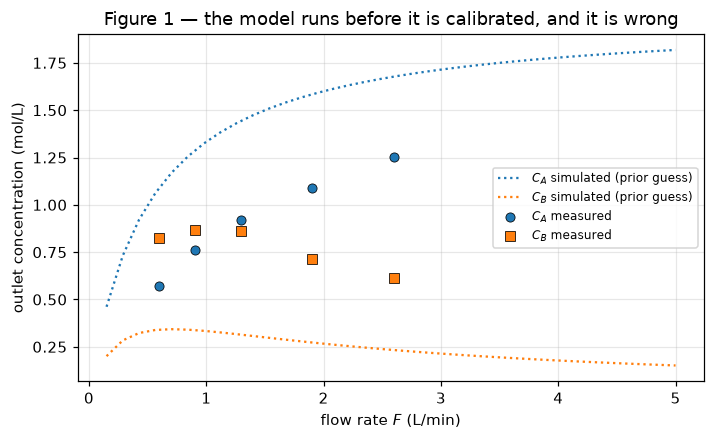

In [6]:
F_dense = np.linspace(0.15, 5.0, 36)
prior_profile = simulate(reactor, GUESS["k1"], GUESS["k2"], F_dense)

fig, ax = plt.subplots(figsize=(6.6, 4.1))
ax.plot(F_dense, prior_profile[:, 0], color="C0", ls=":", label="$C_A$ simulated (prior guess)")
ax.plot(F_dense, prior_profile[:, 1], color="C1", ls=":", label="$C_B$ simulated (prior guess)")
ax.plot(campaign["F"], campaign["CA"], "o", color="C0", mec="k", mew=0.5, label="$C_A$ measured")
ax.plot(campaign["F"], campaign["CB"], "s", color="C1", mec="k", mew=0.5, label="$C_B$ measured")
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("outlet concentration (mol/L)")
ax.set_title("Figure 1 — the model runs before it is calibrated, and it is wrong")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 4. Regress — free the rate constants, pin the flow rates

Same model, five copies of it (`n_runs=5`) sharing one pair of rate constants.
The flow rates are pinned at what was actually run — `lb == ub` *is* how a fixed
variable is expressed — and $k_1, k_2$ are the only things left free. The
objective becomes the weighted sum of squared residuals.

`discopt.estimate` wants an `Experiment` whose `create_model()` returns an
`ExperimentModel` labelling what is unknown, what was controlled and what was
measured. Each run contributes two responses, $C_A$ and $C_B$, both taken
straight off the model with `responses()`.

In [7]:
class Campaign(Experiment):
    """n runs of the reactor at known flow rates -- the regression view."""

    def __init__(self, flows, sigma):
        self.flows = np.asarray(flows, dtype=float)
        self.sigma = np.asarray(sigma, dtype=float)

    def create_model(self, **guess):
        m = build_reactor(len(self.flows), name="cstr_campaign")
        v, _, _ = parts(m)

        v["F"].lb = self.flows.copy()  # pin the conditions that were run
        v["F"].ub = self.flows.copy()
        start = {v[name]: float(val) for name, val in guess.items() if name in v}
        if start:
            m.set_initial_point(start)

        y = responses(m)
        resp, err = {}, {}
        for i in range(len(self.flows)):
            for name in ("CA", "CB"):
                resp[f"{name}_{i}"] = y[name][i]
                err[f"{name}_{i}"] = float(self.sigma[i])
        return ExperimentModel(
            model=m,
            unknown_parameters={"k1": v["k1"], "k2": v["k2"]},
            design_inputs={},
            responses=resp,
            measurement_error=err,
        )


def observations(rows):
    """Assay rows -> the {response_name: value} dict estimate_parameters wants."""
    return {
        f"{name}_{i}": float(rows[name][i])
        for i in range(len(rows["F"]))
        for name in ("CA", "CB")
    }


fit_1 = estimate_parameters(
    Campaign(campaign["F"], campaign["sigma"]),
    observations(campaign),
    initial_guess=GUESS,
)
print(fit_1.summary())

No valid dual bound was produced for model 'cstr_campaign': the relaxation layer could not bound this objective (status=feasible). The result cannot be certified globally optimal. A nonlinear term with no envelope is the usual cause; an epigraph reformulation (minimize z subject to f(x) <= z) often gives the relaxation something to bound.


Parameter Estimation Results
            k1 =      1.52528  ± 0.04033  [1.432, 1.618]
            k2 =     0.417587  ± 0.0284  [0.3521, 0.4831]
     Objective = 4.04436
         N obs = 10
       FIM det = 1.016e+06
      FIM cond = 3.746


:::{note}
discopt reports that it could not certify this fit *globally*. That is expected
and not a failure: nonlinear least squares is run as a local NLP
(`skip_convex_check=True`), because spatial branch-and-bound over a
sum-of-squares surface is rarely what a fit wants. The optimization in §7, where
the certificate does matter, is a global solve.
:::

### Parameters and uncertainties after campaign 1

`EstimationResult` carries the covariance — the inverse Fisher information at the
solution — so standard errors, 95% confidence intervals and the parameter
correlation all come straight off the fit.

In [8]:
def parameter_table(fit, title=""):
    """Render an estimate +/- uncertainty table as Markdown."""
    se, ci = fit.standard_errors, fit.confidence_intervals
    rows = [
        "| parameter | estimate | std. error | 95% CI | rel. error |",
        "|---|---:|---:|:---:|---:|",
    ]
    for name in fit.parameter_names:
        val, s = fit.parameters[name], se[name]
        lo, hi = ci[name]
        rows.append(
            f"| ${name[0]}_{name[1]}$ | {val:.4f} | {s:.4f} | "
            f"[{lo:.4f}, {hi:.4f}] | {100 * s / abs(val):.2f}% |"
        )
    return Markdown(
        f"**{title}**\n\n" + "\n".join(rows) + f"\n\n*Weighted SSE = {fit.objective:.4f} on "
        f"{fit.n_observations} observations; "
        f"corr($k_1$,$k_2$) = {fit.correlation_matrix[0, 1]:+.3f}.*"
    )


parameter_table(fit_1, "Table 1 — campaign 1 (5 flow rates, 10 observations)")

**Table 1 — campaign 1 (5 flow rates, 10 observations)**

| parameter | estimate | std. error | 95% CI | rel. error |
|---|---:|---:|:---:|---:|
| $k_1$ | 1.5253 | 0.0403 | [1.4323, 1.6183] | 2.64% |
| $k_2$ | 0.4176 | 0.0284 | [0.3521, 0.4831] | 6.80% |

*Weighted SSE = 4.0444 on 10 observations; corr($k_1$,$k_2$) = +0.500.*

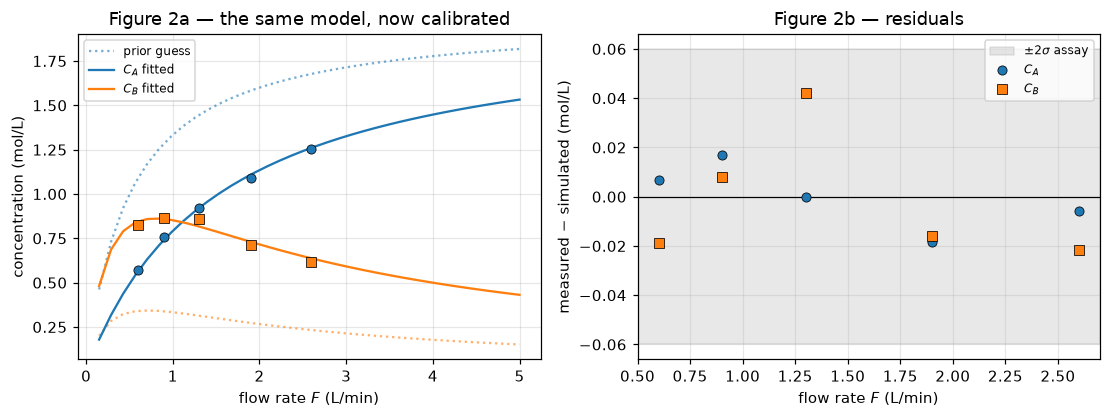

In [9]:
fitted_profile = simulate(reactor, fit_1.parameters["k1"], fit_1.parameters["k2"], F_dense)
at_runs = simulate(reactor, fit_1.parameters["k1"], fit_1.parameters["k2"], campaign["F"])

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

ax = axes[0]
ax.plot(F_dense, prior_profile[:, 0], color="C0", ls=":", alpha=0.6, label="prior guess")
ax.plot(F_dense, prior_profile[:, 1], color="C1", ls=":", alpha=0.6)
ax.plot(F_dense, fitted_profile[:, 0], color="C0", label="$C_A$ fitted")
ax.plot(F_dense, fitted_profile[:, 1], color="C1", label="$C_B$ fitted")
ax.plot(campaign["F"], campaign["CA"], "o", color="C0", mec="k", mew=0.5)
ax.plot(campaign["F"], campaign["CB"], "s", color="C1", mec="k", mew=0.5)
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("concentration (mol/L)")
ax.set_title("Figure 2a — the same model, now calibrated")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
sigma = float(campaign["sigma"][0])
ax.axhline(0, color="k", lw=0.8)
ax.axhspan(-2 * sigma, 2 * sigma, color="grey", alpha=0.18, label=r"$\pm 2\sigma$ assay")
ax.plot(campaign["F"], campaign["CA"] - at_runs[:, 0], "o", color="C0", mec="k", mew=0.5, label="$C_A$")
ax.plot(campaign["F"], campaign["CB"] - at_runs[:, 1], "s", color="C1", mec="k", mew=0.5, label="$C_B$")
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("measured $-$ simulated (mol/L)")
ax.set_title("Figure 2b — residuals")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 5. Serialize the calibrated model

The campaign model was scaffolding — five reactors tied to one pair of rate
constants, useful for one afternoon. What we want to keep is **the reactor,
calibrated**: one instance, carrying what the data taught us.

Three things travel in the file:

* the model itself — variables, bounds, the named definition rows, the rig's
  parameters;
* $\hat\theta$, as the model's **initial point**, which is exactly what a start
  value is: the current best estimate of $k_1$ and $k_2$;
* the **Fisher information** and the observation count, in the `fim` and `n_obs`
  parameters — enough to reconstruct the covariance, the confidence intervals,
  and the prior for the next design.

`Model.save` writes a single JSON document {cite:p}`Fourer2003` — greppable,
diffable, with no pickle and no numpy version baked in — plus a provenance block
recording what wrote it and when.

In [10]:
def save_calibrated(path, fit):
    """Write the reactor with this fit's estimates and information attached."""
    m = build_reactor(1)
    v, p, _ = parts(m)
    m.set_initial_point({v["k1"]: fit.parameters["k1"], v["k2"]: fit.parameters["k2"]})
    p["fim"].value = fit.fim
    p["n_obs"].value = float(fit.n_observations)
    m.save(path, indent=2)
    return path


save_calibrated(CALIBRATED_V1, fit_1)
print(f"{CALIBRATED_V1.name}: {CALIBRATED_V1.stat().st_size} bytes")
print("\n".join(CALIBRATED_V1.read_text().splitlines()[:12]))

cstr_calibrated_v1.dopt: 4625 bytes
{
  "schema": "discopt.model/1.1",
  "discopt": "0.8.1.dev0",
  "name": "cstr",
  "variables": [
    {
      "name": "k1",
      "type": "continuous",
      "shape": [],
      "lb": 0.001,
      "ub": 20.0,
      "bound_stack": []


## 6. Load it back and design the next experiment

A fresh read from disk. Nothing below uses `fit_1` or `reactor` — everything the
next stage needs is in the file.

In [11]:
def estimate_from(m):
    """The parameter estimates a calibrated model carries, from its start point."""
    v, _, _ = parts(m)
    return {name: m.initial_point[v[name]][0] for name in ("k1", "k2")}


def information_from(m):
    """(Fisher information, observation count) carried by a calibrated model."""
    _, p, _ = parts(m)
    return np.asarray(p["fim"].value, dtype=float), int(p["n_obs"].value)


restored = discopt.load(CALIBRATED_V1)
theta_hat = estimate_from(restored)
prior_fim, n_obs = information_from(restored)

print(restored.summary())
print("\nwritten by:", restored.provenance["software"])
print("estimates carried:", {k: round(v, 6) for k, v in theta_hat.items()})
print(f"prior information ({n_obs} observations):\n{prior_fim}")
print(f"\nimplied std. errors: {np.sqrt(np.diag(np.linalg.inv(prior_fim))).round(5)}")

Model: cstr
  Variables: 6 (6 continuous, 0 integer/binary)
  Constraints: 3
  Objective: <none set>
  Parameters: 5

written by: {'name': 'discopt', 'version': '0.8.1.dev0', 'rust_core': '0.2.0', 'repository': 'https://github.com/jkitchin/discopt', 'license': 'EPL-2.0'}
estimates carried: {'k1': 1.525276, 'k2': 0.417587}
prior information (10 observations):
[[ 819.36664978 -581.25980175]
 [-581.25980175 1652.40226739]]

implied std. errors: [0.04033 0.0284 ]


Which flow rate should we run next? MBDoE answers by asking which condition adds
the most **Fisher information** about the parameters {cite:p}`Franceschini2008`:

$$\mathrm{FIM} = J^\top \Sigma^{-1} J, \qquad J_{ij} = \frac{\partial y_i}{\partial \theta_j},$$

evaluated at the current best estimate $\hat\theta$ — sensitivities that
`discopt-doe` gets by autodiff, not finite differences. We maximize
$\det(\mathrm{FIM}_{\text{prior}} + \mathrm{FIM}_{\text{new}})$ (the **D-optimal**
criterion), passing the information *from the file* as the prior, so the design
is genuinely sequential.

This is the third job, and the free/fixed partition has flipped again: $F$ is now
the unknown and $k_1, k_2$ are held at $\hat\theta$. The `Experiment` below builds
its model by **loading the file** — the physics is not written again.

In [12]:
class SavedReactor(Experiment):
    """A calibrated reactor read from disk, with F as the DESIGN variable."""

    def __init__(self, path):
        self.path = str(path)

    def create_model(self, **kwargs):
        m = discopt.load(self.path)
        v, p, _ = parts(m)
        y = responses(m)
        sigma = float(p["sigma"].value)
        return ExperimentModel(
            model=m,
            unknown_parameters={"k1": v["k1"], "k2": v["k2"]},
            design_inputs={"F": v["F"]},
            responses={"CA": y["CA"], "CB": y["CB"]},
            measurement_error={"CA": sigma, "CB": sigma},
        )


design_view = SavedReactor(CALIBRATED_V1)
F_BOUNDS = (0.05, 5.0)

best = doe.optimal_experiment(
    design_view,
    param_values=theta_hat,
    design_bounds={"F": F_BOUNDS},
    criterion="determinant",
    prior_fim=prior_fim,
    seed=1,
)
F_next = float(best.design["F"])
print(f"D-optimal next flow rate: F = {F_next:.4f} L/min  (tau = {1.0 / F_next:.3f} min)")
print(f"log det(FIM) there      : {best.criterion_value:.4f}")

D-optimal next flow rate: F = 0.3116 L/min  (tau = 3.210 min)
log det(FIM) there      : 14.4537


### Why that flow rate?

Scanning the criterion over the whole feasible range shows the design landscape
rather than just its argmax — worth plotting, because a flat optimum means the
exact recommendation hardly matters, while a sharp one means it does.

det(FIM) now: 1.016e+06. A sixth run multiplies it by



  the D-optimal design       F = 0.312 L/min   1.86x


  best F campaign 1 covers   F = 0.637 L/min   1.66x


  repeat the middle run      F = 1.300 L/min   1.38x


  repeat the fastest run     F = 2.600 L/min   1.27x


  the slowest F allowed      F = 0.050 L/min   1.18x


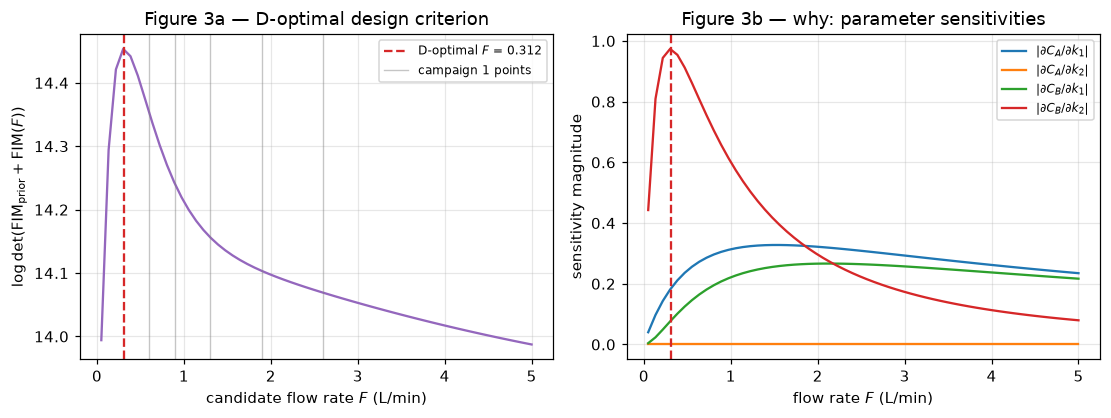

In [13]:
F_grid = np.linspace(F_BOUNDS[0], F_BOUNDS[1], 60)
fims = [doe.compute_fim(design_view, theta_hat, {"F": float(F)}) for F in F_grid]
logdet = np.array([np.log(np.linalg.det(prior_fim + f.fim)) for f in fims])

# What a sixth run is worth, by where you put it: det(FIM) after, over det(FIM) now.
ld_prior = np.log(np.linalg.det(prior_fim))


def worth(F):
    fim = doe.compute_fim(design_view, theta_hat, {"F": float(F)}).fim
    return np.exp(np.log(np.linalg.det(prior_fim + fim)) - ld_prior)


covered = (F_grid >= campaign["F"].min()) & (F_grid <= campaign["F"].max())
candidates = [
    ("the D-optimal design", F_next),
    ("best F campaign 1 covers", float(F_grid[covered][np.argmax(logdet[covered])])),
    ("repeat the middle run", float(campaign["F"][len(campaign["F"]) // 2])),
    ("repeat the fastest run", float(campaign["F"].max())),
    ("the slowest F allowed", float(F_grid[0])),
]
print(f"det(FIM) now: {np.exp(ld_prior):.4g}. A sixth run multiplies it by\n")
for label, F in candidates:
    print(f"  {label:<26s} F = {F:5.3f} L/min   {worth(F):.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.9))

ax = axes[0]
ax.plot(F_grid, logdet, color="C4")
ax.axvline(F_next, color="C3", ls="--", label=f"D-optimal $F$ = {F_next:.3f}")
for F in campaign["F"]:
    ax.axvline(F, color="grey", alpha=0.45, lw=0.9)
ax.plot([], [], color="grey", alpha=0.45, lw=0.9, label="campaign 1 points")
ax.set_xlabel("candidate flow rate $F$ (L/min)")
ax.set_ylabel(r"$\log\det(\mathrm{FIM}_{\rm prior} + \mathrm{FIM}(F))$")
ax.set_title("Figure 3a — D-optimal design criterion")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
J = np.array([f.jacobian for f in fims])
for r, resp in enumerate(fims[0].response_names):
    for p_i, par_name in enumerate(["k_1", "k_2"]):
        ax.plot(F_grid, np.abs(J[:, r, p_i]),
                label=rf"$|\partial {resp[0]}_{resp[1]}/\partial {par_name}|$")
ax.axvline(F_next, color="C3", ls="--")
ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("sensitivity magnitude")
ax.set_title("Figure 3b — why: parameter sensitivities")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

The recommendation is a **low** flow rate — a long residence time — but not the
lowest on offer: the optimum is interior, and the criterion falls away on *both*
sides of it.

Each side fails for its own reason, and the right panel shows both. Run fast and
the second reaction barely gets started, so $C_B$ hardly moves with $k_2$; that is
the blind spot campaign 1 was sitting in, and it is why $k_2$ came out of it with
roughly two and a half times $k_1$'s relative error (Table 1). Run slow enough and
the reactor goes essentially to completion — at the slowest allowed setting the model predicts an
outlet of $C_A \approx 0.06$, $C_B \approx 0.21$ out of a 2.0 mol/L feed — and an
outlet that is nearly all **C** is insensitive to *how fast* it got there. Between
the two, $|\partial C_B/\partial k_2|$ peaks, and that is where the design landed.

The table above the figure prices the alternatives. The gain is real but not
dramatic: no single sixth run transforms this campaign, and simply repeating a
condition already covered is worth a good deal of it. What the design buys is the
*direction* of the improvement — it goes after $k_2$, the parameter campaign 1
left loose, rather than piling more evidence onto $k_1$, which was already the
well-determined one. Table 3 below is where that shows up.

### Send it to the lab

The design goes out as a request for one run at one flow rate, and comes back as
another assay file.

In [14]:
run_6 = DATA / "cstr_run6.csv"
completed = subprocess.run(
    [sys.executable, str(LAB), "--flows", f"{F_next:.4f}", "--seed", "11", "--out", str(run_6)],
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout, end="")

new_run = read_assay(run_6)
refined = {k: np.concatenate([campaign[k], new_run[k]]) for k in ("F", "CA", "CB", "sigma")}

wrote 1 run(s) to /home/user/discopt/docs/notebooks/data/cstr_run6.csv
  F =  0.312 L/min   CA =  0.3450   CB =  0.7659  mol/L


### Refit with all six runs

Back to the regression, unchanged except that the campaign now has six members.
The previous estimates seed the solve.

In [15]:
fit_2 = estimate_parameters(
    Campaign(refined["F"], refined["sigma"]),
    observations(refined),
    initial_guess=theta_hat,
)
parameter_table(fit_2, "Table 2 — after the designed run (6 flow rates, 12 observations)")

No valid dual bound was produced for model 'cstr_campaign': the relaxation layer could not bound this objective (status=feasible). The result cannot be certified globally optimal. A nonlinear term with no envelope is the usual cause; an epigraph reformulation (minimize z subject to f(x) <= z) often gives the relaxation something to bound.


**Table 2 — after the designed run (6 flow rates, 12 observations)**

| parameter | estimate | std. error | 95% CI | rel. error |
|---|---:|---:|:---:|---:|
| $k_1$ | 1.5091 | 0.0372 | [1.4262, 1.5919] | 2.46% |
| $k_2$ | 0.3914 | 0.0203 | [0.3462, 0.4366] | 5.19% |

*Weighted SSE = 6.0254 on 12 observations; corr($k_1$,$k_2$) = +0.437.*

In [16]:
rows = [
    "| parameter | SE before | SE after | change | 95% CI width before | after |",
    "|---|---:|---:|---:|---:|---:|",
]
for name in fit_1.parameter_names:
    s1, s2 = fit_1.standard_errors[name], fit_2.standard_errors[name]
    w1 = np.diff(fit_1.confidence_intervals[name])[0]
    w2 = np.diff(fit_2.confidence_intervals[name])[0]
    rows.append(
        f"| ${name[0]}_{name[1]}$ | {s1:.5f} | {s2:.5f} | "
        f"{100 * (s2 - s1) / s1:+.1f}% | {w1:.4f} | {w2:.4f} |"
    )
d1, d2 = np.linalg.det(fit_1.fim), np.linalg.det(fit_2.fim)
Markdown(
    "**Table 3 — what the single designed experiment bought**\n\n"
    + "\n".join(rows)
    + f"\n\n*det(FIM): {d1:.4g} → {d2:.4g} ({d2 / d1:.2f}×). "
    "One extra run, chosen by the model.*"
)

**Table 3 — what the single designed experiment bought**

| parameter | SE before | SE after | change | 95% CI width before | after |
|---|---:|---:|---:|---:|---:|
| $k_1$ | 0.04033 | 0.03719 | -7.8% | 0.1860 | 0.1657 |
| $k_2$ | 0.02840 | 0.02030 | -28.5% | 0.1310 | 0.0905 |

*det(FIM): 1.016e+06 → 2.169e+06 (2.13×). One extra run, chosen by the model.*

### Serialize the refined model

Same writer, new numbers: a second file, so the two calibrations can be compared
side by side rather than one overwriting the other.

In [17]:
save_calibrated(CALIBRATED_V2, fit_2)

before, after = discopt.load(CALIBRATED_V1), discopt.load(CALIBRATED_V2)
t1, t2 = estimate_from(before), estimate_from(after)
cov1 = np.linalg.inv(information_from(before)[0])
cov2 = np.linalg.inv(information_from(after)[0])

print(f"{'':>4} {'v1 (5 runs)':>22} {'v2 (6 runs)':>22}")
for name in ("k1", "k2"):
    i = ("k1", "k2").index(name)
    print(f"{name:>4} {t1[name]:12.5f} +/- {np.sqrt(cov1[i, i]):.5f} "
          f"{t2[name]:12.5f} +/- {np.sqrt(cov2[i, i]):.5f}")
print(f"\nfiles on disk: {CALIBRATED_V1.name}, {CALIBRATED_V2.name}")

                v1 (5 runs)            v2 (6 runs)
  k1      1.52528 +/- 0.04033      1.50907 +/- 0.03719
  k2      0.41759 +/- 0.02840      0.39141 +/- 0.02030

files on disk: cstr_calibrated_v1.dopt, cstr_calibrated_v2.dopt


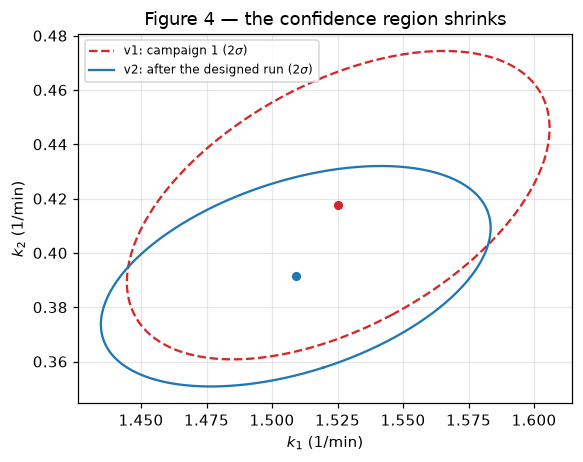

In [18]:
def confidence_ellipse(cov, center, n_std=2.0, n_points=256):
    """Points on the ``n_std``-sigma ellipse of a 2x2 covariance matrix."""
    vals, vecs = np.linalg.eigh(np.asarray(cov, dtype=float))
    t = np.linspace(0.0, 2.0 * np.pi, n_points)
    pts = vecs @ (n_std * np.sqrt(np.maximum(vals, 0.0))[:, None] * np.stack([np.cos(t), np.sin(t)]))
    return pts[0] + center[0], pts[1] + center[1]


c1, c2 = (t1["k1"], t1["k2"]), (t2["k1"], t2["k2"])
fig, ax = plt.subplots(figsize=(5.4, 4.3))
ax.plot(*confidence_ellipse(cov1, c1), color="C3", ls="--", label=r"v1: campaign 1 ($2\sigma$)")
ax.plot(*c1, "o", color="C3", ms=5)
ax.plot(*confidence_ellipse(cov2, c2), color="C0", label=r"v2: after the designed run ($2\sigma$)")
ax.plot(*c2, "o", color="C0", ms=5)
ax.set_xlabel("$k_1$ (1/min)")
ax.set_ylabel("$k_2$ (1/min)")
ax.set_title("Figure 4 — the confidence region shrinks")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## 7. Load the refined model and optimize the flow rate

The last job. We want the flow rate that maximizes the outlet concentration of
the intermediate **B**, with the rate constants now *known* — fixed at their
estimates — and $F$ free. That is the mirror image of the regression, where the
$k$'s were free and $F$ was pinned at whatever we happened to run.

Nothing is rebuilt: the model comes off disk, gets an objective, and is solved.
Unlike the fit, this one is a **global** solve — spatial branch and bound over
the model's own rows — so the answer arrives with a certificate.

In [19]:
final = discopt.load(CALIBRATED_V2)
fv, _, _ = parts(final)
theta_final = estimate_from(final)

final.maximize(fv["CB"])  # the only new thing in the model

with final.fixed({fv["k1"]: theta_final["k1"], fv["k2"]: theta_final["k2"]}):
    opt = final.solve(time_limit=120)

F_opt = float(opt.value(fv["F"]))
CB_opt = float(opt.objective)

print(f"status        : {opt.status}   (gap certified: {opt.gap_certified})")
print(f"nodes         : {opt.node_count}")
print(f"optimal F*    : {F_opt:.6f} L/min   (tau* = {1.0 / F_opt:.6f} min)")
print(f"max outlet C_B: {CB_opt:.6f} mol/L")
depths = (fv["k1"].fix_depth, fv["k2"].fix_depth)
print(f"bounds restored on exit: fix depths {depths} (0 = nothing left pinned)")

status        : optimal   (gap certified: True)
nodes         : 47
optimal F*    : 0.768546 L/min   (tau* = 1.301159 min)
max outlet C_B: 0.877985 mol/L
bounds restored on exit: fix depths (0, 0) (0 = nothing left pinned)


### Check it against the closed form

This particular problem has an analytic optimum, so the numerical answer is
checkable rather than merely plausible. Maximizing
$C_B(\tau) = C_{A0}k_1\tau / \big[(1+k_1\tau)(1+k_2\tau)\big]$ over $\tau$ gives

$$\tau^\star = \frac{1}{\sqrt{k_1 k_2}}, \qquad F^\star = V\sqrt{k_1 k_2}.$$

`simulate()` is reused here on the model that now carries `maximize CB`, and that
is not a slip: with $k_1$, $k_2$ and $F$ all pinned the feasible set is a single
point, so the objective has nothing left to choose between. Which is the thesis of
this notebook, stated as an edge case.

In [20]:
_, fp, _ = parts(final)
V_val = float(fp["V"].value)
F_closed = V_val * np.sqrt(theta_final["k1"] * theta_final["k2"])
CB_closed = simulate(final, theta_final["k1"], theta_final["k2"], F_closed)[0, 1]

print(f"solver     : F* = {F_opt:.9f}   C_B* = {CB_opt:.9f}")
print(f"closed form: F* = {F_closed:.9f}   C_B* = {CB_closed:.9f}")
print(f"difference : dF = {abs(F_opt - F_closed):.2e}   dC_B = {abs(CB_opt - CB_closed):.2e}")

assert abs(F_opt - F_closed) < 1e-6, "solver disagrees with the closed form"
assert abs(CB_opt - CB_closed) < 1e-6
print("\nagreement verified")

solver     : F* = 0.768545582   C_B* = 0.877985093
closed form: F* = 0.768545572   C_B* = 0.877985093
difference : dF = 9.79e-09   dC_B = 1.47e-12

agreement verified


### How much does parameter uncertainty move the optimum?

The optimum is computed from *estimates*, so it inherits their uncertainty.
Propagating each file's covariance through $F^\star = V\sqrt{k_1 k_2}$ by sampling
gives an honest interval on the recommended set point — and shows what the
designed run bought in the units the plant actually cares about.

In [21]:
rng = np.random.default_rng(0)


def propagate(center, cov, size=4000):
    """95% interval on F* = V sqrt(k1 k2) implied by a calibration."""
    draws = rng.multivariate_normal(list(center), cov, size=size)
    draws = draws[(draws > 0).all(axis=1)]
    F_star = V_val * np.sqrt(draws[:, 0] * draws[:, 1])
    lo, hi = np.percentile(F_star, [2.5, 97.5])
    return float(np.mean(F_star)), float(lo), float(hi)


m1, lo1, hi1 = propagate(c1, cov1)
m2_, lo, hi = propagate(c2, cov2)
print(f"F* from {CALIBRATED_V1.name}: {m1:.4f}  [{lo1:.4f}, {hi1:.4f}]  (width {hi1 - lo1:.4f})")
print(f"F* from {CALIBRATED_V2.name}: {m2_:.4f}  [{lo:.4f}, {hi:.4f}]  (width {hi - lo:.4f})")
print(f"the designed run narrowed the recommendation by {100 * (1 - (hi - lo) / (hi1 - lo1)):.0f}%")

F* from cstr_calibrated_v1.dopt: 0.7978  [0.7292, 0.8652]  (width 0.1360)
F* from cstr_calibrated_v2.dopt: 0.7679  [0.7181, 0.8179]  (width 0.0998)
the designed run narrowed the recommendation by 27%


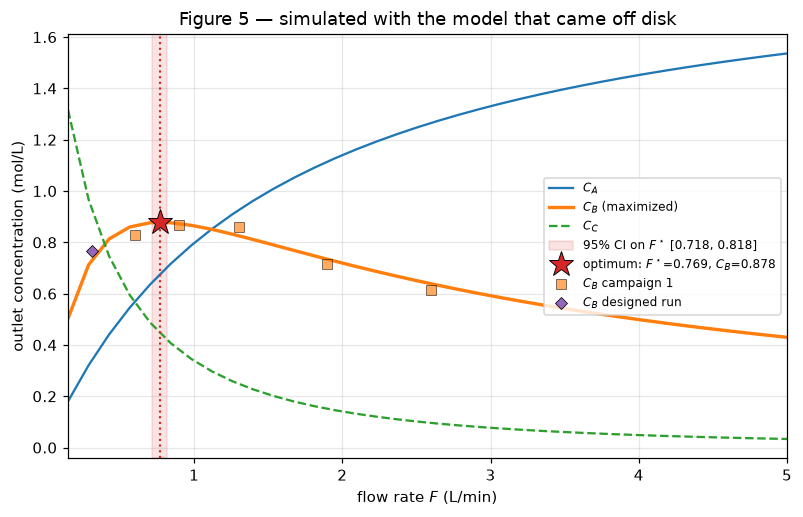

In [22]:
profile = simulate(final, theta_final["k1"], theta_final["k2"], F_dense)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(F_dense, profile[:, 0], color="C0", label="$C_A$")
ax.plot(F_dense, profile[:, 1], color="C1", lw=2.2, label="$C_B$ (maximized)")
ax.plot(F_dense, profile[:, 2], color="C2", ls="--", label="$C_C$")

ax.axvspan(lo, hi, color="C3", alpha=0.13, label=f"95% CI on $F^\\star$ [{lo:.3f}, {hi:.3f}]")
ax.axvline(F_opt, color="C3", ls=":", lw=1.4)
ax.plot([F_opt], [CB_opt], "*", ms=17, color="C3", mec="k", mew=0.6, zorder=5,
        label=f"optimum: $F^\\star$={F_opt:.3f}, $C_B$={CB_opt:.3f}")
ax.plot(campaign["F"], campaign["CB"], "s", color="C1", mec="k", mew=0.5, alpha=0.65,
        label="$C_B$ campaign 1")
ax.plot(new_run["F"], new_run["CB"], "D", color="C4", mec="k", mew=0.5, label="$C_B$ designed run")

ax.set_xlabel("flow rate $F$ (L/min)")
ax.set_ylabel("outlet concentration (mol/L)")
ax.set_title("Figure 5 — simulated with the model that came off disk")
ax.legend(fontsize=8, loc="center right")
ax.grid(alpha=0.3)
ax.set_xlim(F_dense[0], F_dense[-1])
plt.show()

## 8. Open the envelope

Every number above came from the six measurements. Now, and only now, we ask
`cstr_lab.py` what it was actually simulating.

In [23]:
truth = json.loads(
    subprocess.run([sys.executable, str(LAB), "--reveal"],
                   check=True, capture_output=True, text=True).stdout
)
F_true = truth["V"] * np.sqrt(truth["k1"] * truth["k2"])

rows = ["| quantity | estimated | true | error |", "|---|---:|---:|---:|"]
for i, name in enumerate(("k1", "k2")):
    est, se = theta_final[name], np.sqrt(cov2[i, i])
    rows.append(
        f"| ${name[0]}_{name[1]}$ (1/min) | {est:.4f} $\\pm$ {se:.4f} | "
        f"{truth[name]:.4f} | {est - truth[name]:+.4f} ({abs(est - truth[name]) / se:.1f}$\\sigma$) |"
    )
rows.append(
    f"| $F^\\star$ (L/min) | {F_opt:.4f} [{lo:.3f}, {hi:.3f}] | {F_true:.4f} | {F_opt - F_true:+.4f} |"
)
Markdown(
    "**Table 4 — the analysis, scored**\n\n"
    + "\n".join(rows)
    + f"\n\n*Designed flow rate: {F_next:.4f} L/min. "
    f"Information gain: det(FIM) ×{d2 / d1:.2f}. "
    f"Maximum outlet $C_B$ = {CB_opt:.4f} mol/L "
    f"({100 * CB_opt / float(fp['CA0'].value):.1f}% of the feed), "
    f"solver status `{opt.status}`, gap certified: {opt.gap_certified}.*"
)

**Table 4 — the analysis, scored**

| quantity | estimated | true | error |
|---|---:|---:|---:|
| $k_1$ (1/min) | 1.5091 $\pm$ 0.0372 | 1.5000 | +0.0091 (0.2$\sigma$) |
| $k_2$ (1/min) | 0.3914 $\pm$ 0.0203 | 0.4000 | -0.0086 (0.4$\sigma$) |
| $F^\star$ (L/min) | 0.7685 [0.718, 0.818] | 0.7746 | -0.0061 |

*Designed flow rate: 0.3116 L/min. Information gain: det(FIM) ×2.13. Maximum outlet $C_B$ = 0.8780 mol/L (43.9% of the feed), solver status `optimal`, gap certified: True.*

## 9. What to take away

One model answered four questions, and between each pair of questions it lived in
a file rather than in memory:

| job | free | fixed | objective | model came from |
|---|---|---|---|---|
| simulate | $C_A, C_B, C_C$ | $k_1, k_2, F$ | none (square) | `build_reactor()` |
| regress | $k_1, k_2$ | $F$ at each run | min weighted SSE | `build_reactor(n)` |
| design | $F$ | $k_1, k_2$ at $\hat\theta$ | max $\det \mathrm{FIM}$ | `cstr_calibrated_v1.dopt` |
| optimize | $F$ | $k_1, k_2$ at $\hat\theta$ | max $C_B$ | `cstr_calibrated_v2.dopt` |

Three things are worth carrying away.

**The free/fixed partition is the whole difference.** `lb == ub` is how discopt
says "fixed", and `Model.fixed` scopes it to a block, because bounds are re-read
at every solve and a stray fix would silently redefine the next problem while
still reporting `optimal`. Nothing else about the reactor changed across the four
jobs — not one equation was written twice.

**A calibrated model is a deliverable, not a session.** What the file carries is
the model *plus* what the data taught us: the estimates as the start point, the
Fisher information and observation count as parameters. That is enough for the
next stage to design an experiment, put an interval on a recommendation, and pick
up where the last one stopped — which is what makes the design in §6 sequential
rather than a fresh start.

**The designed experiment was chosen where the model said information was**, not
where it was convenient to run, and one such run tightened $k_2$ more than a
sixth point in the range already covered would have — the standard MBDoE result
{cite:p}`Franceschini2008,BoxLucas1959`. Note that "where the information is" was
an interior optimum, not the extreme of the range: the criterion answered a
question that eyeballing the residuals would not have. And the optimum inherits
the parameters' uncertainty, so reporting $F^\star$ without the interval in
Figure 5 would overstate what six measurements support {cite:p}`Bard1974`.

The loop here was run one round by hand to keep each step visible.
`discopt.doe.sequential_doe` automates the cycle when you can hand it a callable
that runs an experiment. For the file format itself — what round-trips, what it
refuses to write, and the provenance block — see
[Saving and loading models](model_serialization.ipynb).

Full citation details for the works above are on the
[references](../references.md) page.